# Aufgabe 2
Für Aufgabe 2 haben wir uns für den freinen Fall als Bewegungsvorgang entscheiden.
Dabei analysieren wir folgende Punkte:
- Ermittlung der Geschwindigkeit
- Kann Luftwiderstand vernachlässigt werden?
- Wie viel kinetische Energie verliert der Körper beim Aufprall?
- Ermittlung des Elastizitätskoeffizienten $e$

## Messung

Für die Messung wurde ein Ball, mit Radius $0.35m$ und einer Masse von $0.018kg$ von einer Höhe vomn $0.8m$ fallen gelassen. Dabei hatte der Ball eine Masse von 18g und einen Radius von $3.5cm$. Während des falles wurde mit einer Kamera mit 240fps die Bewegung aufgenommen.
Als Bewegungsgleichung wird die Formel für den freien Fall verwendet:
$$ s(t) =\frac{1}{2}gt^2 $$
Man sieht in der [Abbildung @fig-freier-fall-y], dass die Messwerte leivht unter der theoretischen Kurve liegen. Dies ist darauf zurückzuführen auf dieverse Messfehler. So wurde das Video wirkt schräg aufgenommen, was aber nicht stimmt, da der Boden ungünstiger weise leicht angeschrägt war ($\approx 2°$) was in dem Video aber viel stärker rüberkommt. Jedoch wurde daruf beim Tracken der Daten extra darauf geachtet das der Ball gut getrackt ist und auf ähnlicher höhe ist wie das Maßband im Hintergrund. Zudem sieht man im Video aber, dass der Ball relativ gerade herunterfällt, weswegen nicht schräg gefilmt wurde.

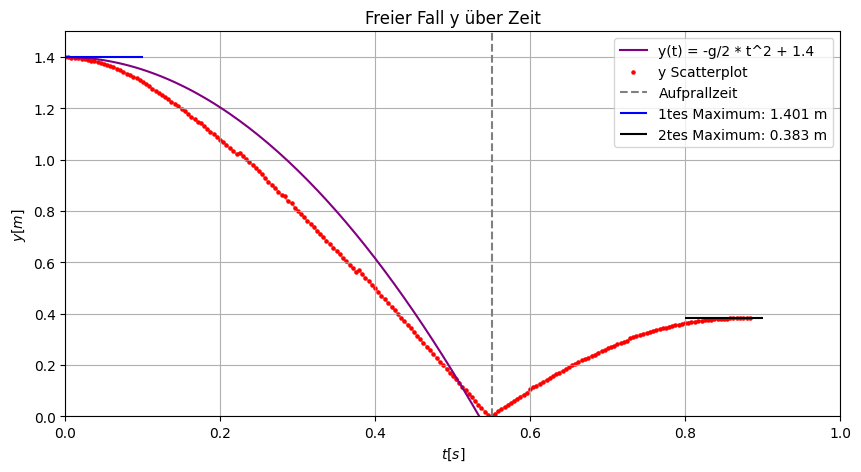

In [ ]:
#| label: fig-freier-fall-y
#| fig-cap: "Freier Fall y über Zeit mit Theoretischen Graphen"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

aufprall_zeit = 0.55 #[s]

max1 = 1.401 #[m]
max2 = 0.383 #[m]

df = pd.read_csv("Aufgabe_2_Daten/data2.csv")

t = df["t"].to_numpy()
x = df["x"].to_numpy()
y = df["y"].to_numpy()

g = 9.81 #[m/s^2]
# t ist in "Zeitlupe" und 8 mal so lang wie die originale Zeit. Wir skalieren t auf die reale Zeit.
t_real = t
y_t = -g/2 * t_real**2 + 1.4

# Gegebene Werte
m = 0.018  # Masse in kg
h0 = 1.4   # Anfangshöhe in m
r = 0.035   # geschätzter Radius des Balls in m
rho = 1.225  # Luftdichte in kg/m^3
cw = 0.47    # Luftwiderstandsbeiwert für eine Kugel
A = np.pi * r**2  # Querschnittsfläche in m²

# Luftwiderstandskoeffizient
c = 0.5 * cw * rho * A

# Neue Differentialgleichung: dv/dt = g - (c/m) * v * |v|
def dvdt(v, t):
    return g - (c/m) * v * abs(v)

# Anfangsbedingungen
v0 = 0.0        # Anfangsgeschwindigkeit (m/s)

# Geschwindigkeit über die Zeit
v = odeint(dvdt, v0, t_real).flatten()

# Höhe y über Zeit: dy/dt = v, Start bei h0
y_luft = h0 - np.cumsum(v) * (t_real[1] - t_real[0])


# Plot the raw data
plt.figure(figsize=(10, 5))
plt.plot(t_real, y, color="red", alpha=0.5)
plt.plot(t_real, y_t, "-", label="y(t) = -g/2 * t^2 + 1.4", color="purple")
#plt.plot(t_real, y_luft, "--" ,label="y(t) mit Luftwiderstand", color="orange")
plt.scatter(t_real, y, label="y Scatterplot", color="red", s=5)
plt.xlabel("$t [s]$")
plt.ylabel("$y [m]$")
plt.title("Freier Fall y über Zeit")
plt.axvline(x=aufprall_zeit, color="gray", linestyle="--", label="Aufprallzeit")
plt.hlines(max1, xmax=0.1, xmin=0, color="blue", linestyle="-", label=f"1tes Maximum: {max1} m")
plt.hlines(max2, xmax=0.8, xmin=0.9, color="black", linestyle="-", label=f"2tes Maximum: {max2} m")
plt.xlim(0, 1)
plt.ylim(0, 1.5)
plt.legend()
plt.grid()
plt.show()

## Ermittlung der Geschwindigkeit
Die Geschwindigkeit wird mit der Formel $v(t) = \frac{ds}{dt}$ ermittelt. Dies konnte gleich in der Tracker Software gemacht werden. Welche durch numerisches Ableiten die Geschwindigkeit ermittelt.
In [Abbildung @fig-freier-fall-v] sieht man großes Schwankungen der Geschwindigkeit was zurückzuführen ist, dass der Ball sich gedreht hat und der Track somit nicht immer genau war und so die Abbleitung noch ungenauer ist durch Fehlerfortpflanzung, weshalb auch nicht die Beschleunigung geplottet wurde, dar diese nicht gut auswertbar ist.
In der Abbildung kommt man auf eine maximale Herunterfallgeschwindigkeit von $v_{fallmax} = -3.699m/s$ und auf eine maximale Geschwindigkeit nach dem Aufprall von $v_{aufmax} = 2.356m/s$. 

Maxima:  2.356 m/s
Minima:  -3.699 m/s


[]

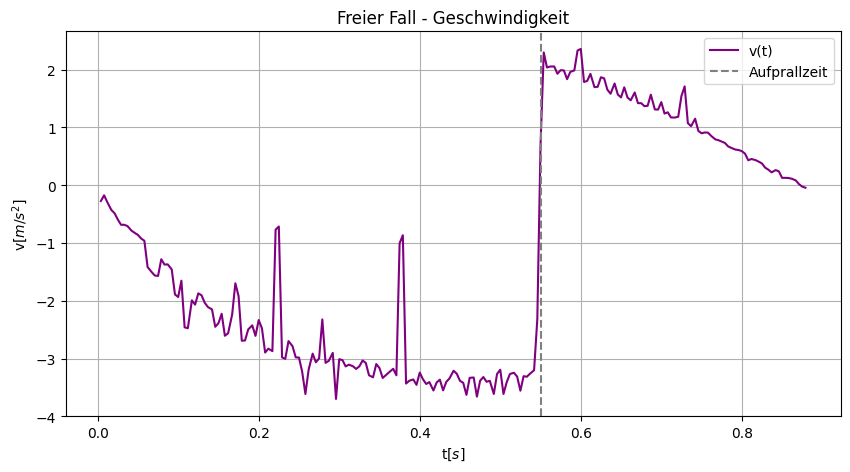

In [ ]:
#| fig-cap: "Freier Fall - Geschwindigkeit in y-Richtung"
#| label: fig-freier-fall-v

df = pd.read_csv("Aufgabe_2_Daten/data2.csv")

t = df["t"].to_numpy()
v = df["vy"].to_numpy()

# Print maximas und minimas (ignoring NaN values)
print("Maxima: ", np.nanmax(v), "m/s")
print("Minima: ", np.nanmin(v), "m/s")


plt.figure(figsize=(10, 5))
plt.plot(t, v, "-", label="v(t)", color="purple")
plt.xlabel("t$ [s]$")
plt.ylabel("v$ [m/s^2]$")
plt.title("Freier Fall - Geschwindigkeit")
plt.axvline(x=aufprall_zeit, color="gray", linestyle="--", label="Aufprallzeit")
plt.grid(True)
plt.legend()
plt.plot()

## Kann Luftwiderstand vernachlässigt werden?
Eine wichitge Frage in der Physik ist, was man vernachlässigen kan um siene Berechungen einfacher und übersichlicher zu gestalten. Daberi stellt sich die Frage ws darf ich alles vernachlässigen? In diesem Experiment wird am Anfang der Luftwiederstand vernachlässigt. Dabei wird die Bewegung eines Körpers im freien Fall unter Einfluss des Luftwiderstands wird beschrieben durch die folgende Differentialgleichung:
$$\frac{dv}{dt} = g - \frac{c}{m}v^2$$
wobei $c$ gegeben ist durch:
$$c = \frac{1}{2} \cdot \rho \cdot A \cdot c_w$$
Dabei wird als $c_w$ Wert 0.47 angenommen und für die Dichte der Luft $1.225 \frac{kg}{m^3}$.
Die Hühe $y(t)$ ergibt sich dann aus mittels numerischen Integration mit `scipy.odeint` aus der Geschwindigkeit $v(t)$ die aus der Differentialgeleichung folgt.
$$y(t) = y_0 - \int_0^t v(t') dt'$$
Wie in [Abbildung @fig-freier_fall_y_luft] zu sehen ist, liegt die Bewegungsgleichung für den freien Fall unter Einfluss des Luftwiderstands zwar näher bei den Messwerten, jedoch ist der Unterschied nicht sehr groß. Daher kann gefolgert werden, dass der Luftwiderstand vernachlässigbar ist wenn man keine sehr genauen Werte benötigt.

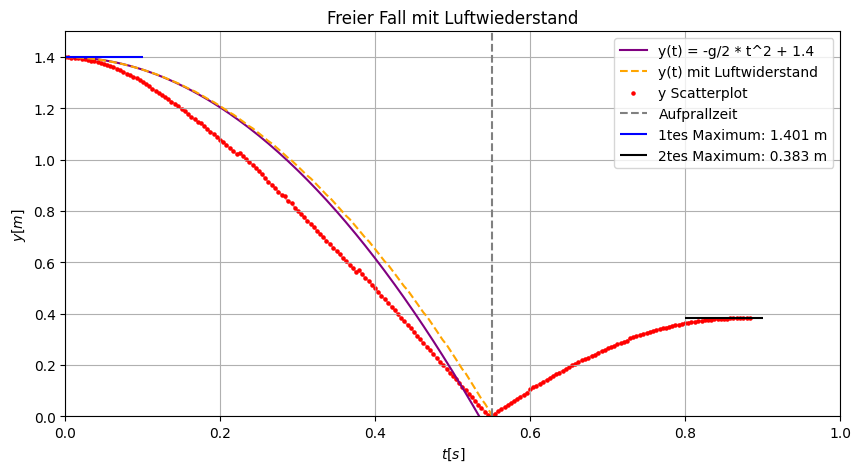

In [ ]:
#| label: fig-freier_fall_y_luft
#| fig-cap: "Freier Fall y über Zeit mit Luftwiderstand"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

aufprall_zeit = 0.55 #[s]

max1 = 1.401 #[m]
max2 = 0.383 #[m]

df = pd.read_csv("Aufgabe_2_Daten/data2.csv")

t = df["t"].to_numpy()
x = df["x"].to_numpy()
y = df["y"].to_numpy()

g = 9.81 #[m/s^2]
# t ist in "Zeitlupe" und 8 mal so lang wie die originale Zeit. Wir skalieren t auf die reale Zeit.
t_real = t
y_t = -g/2 * t_real**2 + 1.4

# Gegebene Werte
m = 0.018  # Masse in kg
h0 = 1.4   # Anfangshöhe in m
r = 0.035   # geschätzter Radius des Balls in m
rho = 1.225  # Luftdichte in kg/m^3
cw = 0.47    # Luftwiderstandsbeiwert für eine Kugel
A = np.pi * r**2  # Querschnittsfläche in m²

# Luftwiderstandskoeffizient
c = 0.5 * cw * rho * A

# Neue Differentialgleichung: dv/dt = g - (c/m) * v * |v|
def dvdt(v, t):
    return g - (c/m) * v * abs(v)

# Anfangsbedingungen
v0 = 0.0        # Anfangsgeschwindigkeit (m/s)

# Geschwindigkeit über die Zeit
v = odeint(dvdt, v0, t_real).flatten()

# Höhe y über Zeit: dy/dt = v, Start bei h0
y_luft = h0 - np.cumsum(v) * (t_real[1] - t_real[0])


# Plot the raw data
plt.figure(figsize=(10, 5))
plt.plot(t_real, y, color="red", alpha=0.5)
plt.plot(t_real, y_t, "-", label="y(t) = -g/2 * t^2 + 1.4", color="purple")
plt.plot(t_real, y_luft, "--" ,label="y(t) mit Luftwiderstand", color="orange")
plt.scatter(t_real, y, label="y Scatterplot", color="red", s=5)
plt.xlabel("$t [s]$")
plt.ylabel("$y [m]$")
plt.title("Freier Fall mit Luftwiederstand")
plt.axvline(x=aufprall_zeit, color="gray", linestyle="--", label="Aufprallzeit")
plt.hlines(max1, xmax=0.1, xmin=0, color="blue", linestyle="-", label=f"1tes Maximum: {max1} m")
plt.hlines(max2, xmax=0.8, xmin=0.9, color="black", linestyle="-", label=f"2tes Maximum: {max2} m")
plt.xlim(0, 1)
plt.ylim(0, 1.5)
plt.legend()
plt.grid()
plt.show()

## Energieverlust beim Aufprall
Wie in dem Video klar erkenntlich ist, springt der Ball nach dem Aufprall wieder hoch. Dabei verliert der Ball kinetische Energie. Um diese verlorenen Energie zu berechnen nutzten wir die potentielle Energie $ E_{pot} = m g h $ am Anfangspunkt bei $h_1 = 1.401m$ und am höchsten Punkt nach dem Aufprall, was in der Analyse bei $h_2 = 0.383m$ war, und berechnen uns die Differenz zwischne den beiden Energien.
$$\Delta E = E_{pot1} - E_{pot2} = mgh_1-mgh_2=mg\cdot (h_1 - h_2)$$
$$\Delta E = 0.018kg \cdot 9.81 \frac{m}{s^2} \cdot (1.401m - 0.383m) \approx 0.179J$$
Die Energie die der Ball verliert beträgt also ungefähr $0.179J$.
Man sollte jedoch beachten das dieser Wert nur eine Näherung ist, da der Ball nicht elastisch ist und auch noch andere Faktoren wie Luftwiderstand und Reibung eine Rolle spielen. Zudem war der Untergrund nicht besonders gerade weshalb der Ball mit einem Winkel abprallte und nicht senkrecht zurücksprang. Dies führt dazu das der Ball nicht die gesamte kinetische Energie in potentielle Energie umwandelt.


## Ermittlung des Elastizitätskoeffizienten $e$
Der Elastizitätskoeffizient $e$ ist ein Maß dafür, wie elastisch ein Körper ist. Er wird definiert als das Verhältnis der Geschwindigkeit des Körpers nach dem Aufprall zur Geschwindigkeit vor dem Aufprall:
$$e = \frac{E_{2}}{E_{1}} = \frac{v_{2}}{v_{1}} = \frac{h_{2}}{h_{1}}$$
Hierbei entscheidet man sich für den letzteren Ausdruck da diese einen kleineren Fehler hat, da die Geschwindigkeit durch Fehlerfortphlanzung nur einen größeren Fehler haben können als die Höhe. So berechnet man für die Höhen  $h_1 = 1.401m$ und $h_2 = 0.383m$ eine Elastizitätskoeffizient von:
$$e = \frac{h_{2}}{h_{1}} = \frac{0.383m}{1.401m} \approx 0.273$$
Dies bedeutet, dass der Ball nur 27.3% der Energie zurückgewinnt, die er beim Aufprall verloren hat. Dies ist ein relativ niedriger Wert und deutet darauf hin, dass der Ball nicht sehr elastisch ist. Dies ist auch zu erwarten, da der Ball aus einem weichen schaumstoff ähnlichen Material besteht und nicht perfekt elastisch ist.